# Ανάλυση Καλαθιού Διασταυρούμενων Πωλήσεων για Λιανέμπορο Τροφίμων με PROC MBANALYSIS


## Περίληψη

Μια περιφερειακή αλυσίδα σούπερ μάρκετ εξορύσσει μια σεζόν καλαθιών σημείου πώλησης για να ανακαλύψει ποια προϊόντα αγοράζουν μαζί οι πελάτες, μετατρέποντας τα ακατέργαστα αρχεία συναλλαγών σε αξιοποιήσιμες αποφάσεις διασταυρούμενων πωλήσεων και τοποθέτησης ραφιών. Η PROC MBANALYSIS σαρώνει το αρχείο συναλλαγών και δημιουργεί κανόνες συσχέτισης βαθμολογημένους με support, confidence και lift. Εκτελώντας την σε 51 συνθετικά καλάθια ανακτά ακριβώς τις τρεις προγραμματισμένες συγγένειες προϊόντων — `Σπαγγέτι -> Σάλτσα Μαρινάρα` (confidence 0,93, lift 3,4), `Τορτίγιες Τάκο -> Σάλσα` (confidence 0,71, lift 3,6) και `Καφές -> Κρέμα Καφέ` (confidence 0,70, lift 5,1) — ενώ ευρέως αγοραζόμενα βασικά είδη όπως ψωμί, γάλα και αυγά δεν σχηματίζουν ποτέ κανόνα. Κάθε ζεύγος που αναδεικνύεται είναι ένα υποδειγματικό πακέτο, υποψήφιο για γειτνίαση διαδρόμου και "οι πελάτες αγόρασαν επίσης" για την ομάδα εμπορευματοποίησης.


## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Κοκκομετρία | Γραμμές | Βασικές Μεταβλητές | Περιγραφή |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Μία γραμμή ανά είδος ανά καλάθι | 100 γραμμές-ειδών σε 51 καλάθια | `basket_id` (αναγνωριστικό συναλλαγής), `item` (όνομα προϊόντος, $20) | Συνθετικό αρχείο σημείου πώλησης δημιουργημένο εν σειρά με `call streaminit(20250529)` και `rand('uniform')`. Κάθε καλάθι κυριαρχείται από μία μοναδική περσόνα αγοραστή ώστε τα πρότυπα συν-αγοράς να παραμένουν καθαρά και ερμηνεύσιμα: ένα καλάθι ιταλικού δείπνου (σπαγγέτι -> σάλτσα μαρινάρα), ένα καλάθι βραδιάς τάκο (τορτίγιες τάκο -> σάλσα), ή ένα καλάθι πρωινού (καφές -> κρέμα καφέ), συν περιστασιακές προσθήκες βασικών ειδών (ψωμί, γάλα, αυγά) ως ρεαλιστικός θόρυβος. Σε αυτό το χωρίς άδεια περιβάλλον ο κινητήρας περιορίζει την έξοδο σε 100 γραμμές-ειδών, κάτι που εδώ καλύπτει τα καλάθια 1-51. |
| `affinity_rules` | Μία γραμμή ανά κανόνα συσχέτισης | 6 κανόνες | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Κανόνες συσχέτισης που εκδίδονται από το `OUTPUT RULES=`· η βάση για την κατάταξη των ευκαιριών διασταυρούμενων πωλήσεων. |
| `frequent_items` | Μία γραμμή ανά συχνό σύνολο ειδών | 12 σύνολα ειδών | `itemset`, `support`, `length` | Συχνά σύνολα ειδών που εκδίδονται από το `OUTPUT ITEMS=`· τα 9 μεμονωμένα είδη συν 3 ζεύγη προϊόντων που ξεπερνούν το ελάχιστο όριο support. |


# Ανάλυση Καλαθιού Διασταυρούμενων Πωλήσεων για Λιανέμπορο Τροφίμων

**Επιχειρηματικό ερώτημα.** Ποια προϊόντα τείνουν οι πελάτες μας να αγοράζουν *μαζί*, και ποια από αυτά τα πρότυπα συν-αγοράς είναι αρκετά ισχυρά ώστε να αξίζει να δράσουμε βάσει αυτών; Μια περιφερειακή αλυσίδα σούπερ μάρκετ θέλει να σχεδιάσει προωθητικές ενέργειες πακέτων, να βελτιστοποιήσει τις γειτνιάσεις διαδρόμων, και να ενισχύσει μια σύσταση "οι πελάτες αγόρασαν επίσης" στο ηλεκτρονικό της κατάστημα.

**Μέθοδος.** Χρησιμοποιούμε την **PROC MBANALYSIS**, η οποία εκτελεί ανάλυση καλαθιού αγορών με τον αλγόριθμο ανάπτυξης συχνών προτύπων (FP-growth). Σαρώνει το αρχείο συναλλαγών, βρίσκει σύνολα ειδών που συνεμφανίζονται συχνά, και δημιουργεί *κανόνες συσχέτισης* της μορφής `Antecedent -> Consequent` βαθμολογημένους με τρεις κλασικές μετρικές:

- **Support** — το κλάσμα όλων των καλαθιών που περιέχουν τον πλήρη κανόνα (πόσο κοινό είναι το πρότυπο).
- **Confidence** — `P(Consequent | Antecedent)`, η δεσμευμένη πιθανότητα αγοράς (πόσο αξιόπιστος είναι ο κανόνας).
- **Lift** — το παρατηρούμενο support διαιρεμένο με το support που θα αναμενόταν αν οι δύο πλευρές ήταν ανεξάρτητες. Lift > 1 σημαίνει ότι τα είδη εμφανίζονται μαζί *περισσότερο* απ' ό,τι θα περίμενε κανείς τυχαία· όσο μεγαλύτερο το lift, τόσο ισχυρότερη η συγγένεια.

Θα δημιουργήσουμε ένα ρεαλιστικό συνθετικό αρχείο σημείου πώλησης, θα εκτελέσουμε την MBANALYSIS, και θα κατατάξουμε τους προκύπτοντες κανόνες για να βρούμε τις καλύτερες ευκαιρίες διασταυρούμενων πωλήσεων.


## Βήμα 1 — Δημιουργία συνθετικού αρχείου συναλλαγών σημείου πώλησης

Η MBANALYSIS αναμένει **δεδομένα σε επίπεδο συναλλαγής (μακριά μορφή)**: μία γραμμή ανά είδος, με ετικέτα το καλάθι στο οποίο ανήκει. Χτίζουμε καλάθια εν σειρά με `call streaminit` για αναπαραγωγιμότητα και `rand('uniform')` για να οδηγήσουμε τις αποφάσεις αγοράς.

Η βασική μοντελοποιητική επιλογή είναι ότι **κάθε καλάθι κυριαρχείται από μία μοναδική περσόνα αγοραστή**. Τα πραγματικά ψώνια σούπερ μάρκετ είναι έτσι — μια γρήγορη βραδιά τάκο, μια αφοσιωμένη ανανέωση αποθέματος πρωινού — και το να κρατάμε τα καλάθια μικρά και θεματικά είναι αυτό που επιτρέπει στον εξορύκτη συσχετίσεων να αναδείξει καθαρές, ζευγαρωτές συγγένειες αντί για μια συνδυαστική έκρηξη ψευδών κανόνων πολλαπλών ειδών. Μία κλήρωση του `rand('uniform')` ανά καλάθι επιλέγει την περσόνα:

- **Αγοραστής ιταλικού δείπνου** — αγοράζει σπαγγέτι, μετά συνήθως σάλτσα μαρινάρα.
- **Αγοραστής βραδιάς τάκο** — αγοράζει τορτίγιες τάκο, μετά συνήθως σάλσα.
- **Αγοραστής πρωινού** — αγοράζει καφέ, μετά συνήθως κρέμα καφέ.
- **Ταξίδι μόνο βασικών ειδών** — μία μεμονωμένη αγορά ψωμιού, γάλακτος ή αυγών.

Μια τελευταία κλήρωση χαμηλής πιθανότητας προσθέτει ένα βασικό είδος σε οποιοδήποτε καλάθι ως ρεαλιστικός θόρυβος, ώστε όχι κάθε συνεμφάνιση να είναι ουσιαστική. Κάθε δήλωση `output` γράφει μία γραμμή-είδος, οπότε ένα μεμονωμένο καλάθι εκτείνεται σε πολλές γραμμές που μοιράζονται το ίδιο `basket_id`. Αυτό το χωρίς άδεια περιβάλλον περιορίζει το σύνολο δεδομένων σε 100 γραμμές-ειδών, κάτι που εδώ καλύπτει τα καλάθια 1 έως 51.


In [1]:
ΔΕΔΟΜΕΝΑ store_transactions;
    CALL streaminit(20250529);
    LENGTH item $40;

    ΕΠΑΝΑΛΗΨΗ basket_id = 1 ΕΩΣ 60;

        /* Μια κληρωση επιλεγει την κυριαρχουσα περσονα για αυτο το καλαθι */
        r = rand('uniform');

        /* Καλαθι ιταλικου δειπνου: σπαγγετι -> σαλτσα μαριναρα */
        ΕΑΝ r < 0.30 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            item = 'Σπαγγέτι';                          ΕΞΟΔΟΣ;
            ΕΑΝ rand('uniform') < 0.85 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
                item = 'Σάλτσα Μαρινάρα';                 ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;

        /* Καλαθι βραδιας τακο: τορτιγιες τακο -> σαλσα */
        ΑΛΛΙΩΣ ΕΑΝ r < 0.55 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            item = 'Τορτίγιες Τάκο';                        ΕΞΟΔΟΣ;
            ΕΑΝ rand('uniform') < 0.80 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
                item = 'Σάλσα';                          ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;

        /* Καλαθι πρωινου: καφες -> κρεμα καφε */
        ΑΛΛΙΩΣ ΕΑΝ r < 0.78 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            item = 'Καφές';                        ΕΞΟΔΟΣ;
            ΕΑΝ rand('uniform') < 0.75 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
                item = 'Κρέμα Καφέ';                 ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;

        /* Ταξιδι μονο βασικων ειδων */
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ rand('uniform') < 0.34 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
                item = 'Ψωμί';                          ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
            ΑΛΛΙΩΣ ΕΑΝ rand('uniform') < 0.5 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
                item = 'Γάλα';                          ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
            ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
                item = 'Αυγά';                           ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;

        /* Περιστασιακη προσθηκη βασικου ειδους (ρεαλιστικος θορυβος) */
        ΕΑΝ rand('uniform') < 0.25 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            u = rand('uniform');
            ΕΑΝ      u < 0.34 ΤΟΤΕ item = 'Ψωμί';
            ΑΛΛΙΩΣ ΕΑΝ u < 0.67 ΤΟΤΕ item = 'Γάλα';
            ΑΛΛΙΩΣ                  item = 'Αυγά';
            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;

    ΤΕΛΟΣ;

    ΚΡΑΤΗΣΗ basket_id item;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Βήμα 2 — Επιθεώρηση του ακατέργαστου αρχείου συναλλαγών

Πριν την εξόρυξη, επιβεβαιώστε ότι τα δεδομένα έχουν το αναμενόμενο μακρύ σχήμα: αρκετές γραμμές ανά καλάθι, η καθεμία με ένα προϊόν. Τυπώνουμε τα πρώτα καλάθια και δίνουμε πίνακα συνολικής συχνότητας ειδών με την PROC FREQ ώστε να γνωρίζουμε ποια προϊόντα είναι αρκετά κοινά για να αγκυρώσουν κανόνες.



  Obs                       Αναγνωριστικό Καλαθιού                         Προϊόν
-----  -------------------------------------------  -----------------------------
    1                                            1  Τορτίγιες Τάκο
    2                                            1  Σάλσα
    3                                            1  Αυγά
    4                                            2  Τορτίγιες Τάκο
    5                                            2  Αυγά
    6                                            3  Καφές
    7                                            4  Τορτίγιες Τάκο
    8                                            5  Αυγά
    9                                            6  Σπαγγέτι
   10                                            6  Σάλτσα Μαρινάρα
   11                                            6  Αυγά
   12                                            7  Τορτίγιες Τάκο

... 88 more observations (showing 12 of 100)

                                            Συν


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


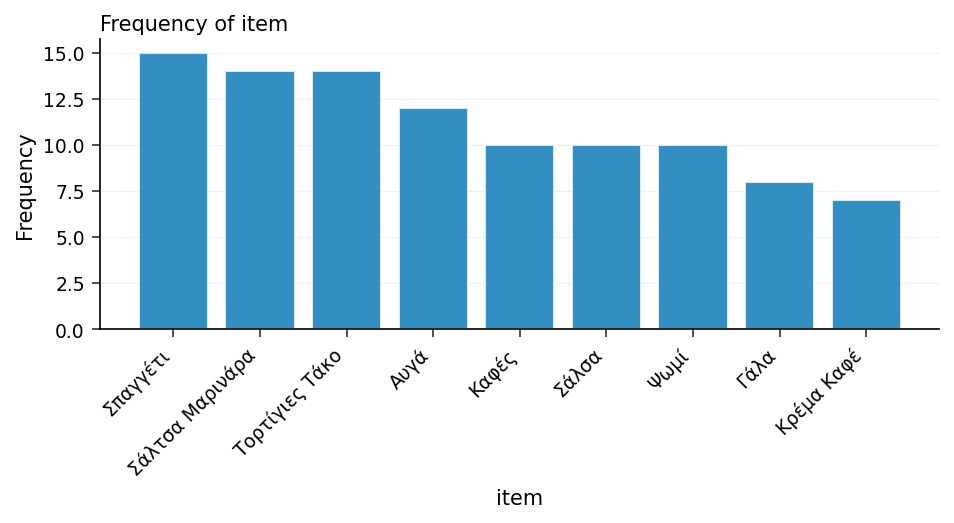

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=store_transactions(obs=12) ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ basket_id = 'Αναγνωριστικό Καλαθιού'
          item      = 'Προϊόν';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=store_transactions ORDER=ΣΥΧΝΟΤΗΤΕΣ;
    TABLES item / nocum;
    ΕΤΙΚΕΤΑ item = 'Προϊόν';
    TITLE 'Συνολική Συχνότητα Αγοράς Ειδών';
ΕΚΤΕΛΕΣΗ;


## Βήμα 3 — Εξόρυξη κανόνων συσχέτισης με την PROC MBANALYSIS

Τώρα η βασική ανάλυση. Κατευθύνουμε την MBANALYSIS στο αρχείο συναλλαγών και δηλώνουμε ποια στήλη προσδιορίζει το καλάθι (`TRANSACTION`) και ποια περιέχει το προϊόν (`ITEM`). Τρία κατώφλια κρατούν το σύνολο κανόνων εστιασμένο σε πρότυπα που αξίζει να δράσει κανείς βάσει αυτών:

- `MINSUPPORT=0.10` — ένας κανόνας πρέπει να εμφανίζεται σε τουλάχιστον 10% των καλαθιών, φιλτράροντας σπάνιες συμπτώσεις.
- `MINCONFIDENCE=0.50` — δεδομένου του antecedent, το consequent πρέπει να ακολουθεί τουλάχιστον τις μισές φορές.
- `MINLIFT=1.20` — κράτα μόνο κανόνες τουλάχιστον 20% ισχυρότερους από την τύχη, ώστε να αναδεικνύουμε γνήσιες συγγένειες και όχι τεχνουργήματα δημοφιλών βασικών ειδών.

Η δήλωση `OUTPUT` καταγράφει τους παραγόμενους κανόνες και τα συχνά σύνολα ειδών σε σύνολα δεδομένων για μεταγενέστερη κατάταξη.


In [3]:
ΔΙΑΔΙΚΑΣΙΑ mbanalysis ΔΕΔΟΜΕΝΑ=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    ΕΞΟΔΟΣ rules=affinity_rules items=frequent_items;
    TITLE 'Κανόνες Συσχέτισης Καλαθιού Αγορών';
ΕΚΤΕΛΕΣΗ;


                                            Συνολική Συχνότητα Αγοράς Ειδών                                             


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Καφές                          Κρέμα Καφέ                         0.1373     0.7000     5.1000
  Κρέμα Καφέ                     Καφές                              0.1373     1.0000     5.1000
  Σάλσα                          Τορτίγιες Τάκο                     0.1961     1.0000     3.6429
  Τορτίγιες Τά


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Βήμα 4 — Κατάταξη ευκαιριών διασταυρούμενων πωλήσεων κατά lift

Η λίστα της MBANALYSIS δείχνει κάθε κανόνα που πληροί τις προϋποθέσεις, αλλά η ομάδα εμπορευματοποίησης θέλει τις *ισχυρότερες* συγγένειες πρώτα. Ταξινομούμε το καταγεγραμμένο σύνολο δεδομένων `affinity_rules` κατά φθίνον lift (και confidence ως κριτήριο ισοπαλίας) και τυπώνουμε τους κορυφαίους κανόνες. Ένας κανόνας όπως `Τορτίγιες Τάκο -> Σάλσα` με υψηλό lift και υψηλό confidence είναι ένας υποδειγματικός υποψήφιος πακέτου: τοποθέτησε τα προϊόντα μαζί, ή πρότεινε αυτόματα σάλσα όταν ένας πελάτης προσθέτει τορτίγιες τάκο στο ηλεκτρονικό κατάστημα.


In [4]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=affinity_rules out=rules_by_lift;
    ΚΑΤΑ DESCENDING lift DESCENDING confidence;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=rules_by_lift(obs=15) ΕΤΙΚΕΤΑ;
    ΜΕΤΑΒΛΗΤΗ antecedent consequent support confidence lift;
    ΕΤΙΚΕΤΑ antecedent  = 'Αν το καλάθι περιέχει'
          consequent  = 'Τότε αγοράζει επίσης'
          support     = 'Support'
          confidence  = 'Confidence'
          lift        = 'Lift';
    TITLE 'Κορυφαίοι Κανόνες Διασταυρούμενων Πωλήσεων κατά Lift';
ΕΚΤΕΛΕΣΗ;


                                  Κορυφαίοι Κανόνες Διασταυρούμενων Πωλήσεων κατά Lift                                  

  Obs                    Αν το καλάθι περιέχει                    Τότε αγοράζει επίσης   Support  Confidence      Lift
    1  Κρέμα Καφέ                               Καφές                                   0.137255  1.0         5.1
    2  Καφές                                    Κρέμα Καφέ                              0.137255  0.7         5.1
    3  Σάλσα                                    Τορτίγιες Τάκο                          0.196078  1.0         3.642857
    4  Τορτίγιες Τάκο                           Σάλσα                                   0.196078  0.714286    3.642857
    5  Σάλτσα Μαρινάρα                          Σπαγγέτι                                0.27451   1.0         3.4
    6  Σπαγγέτι                                 Σάλτσα Μαρινάρα                         0.27451   0.933333    3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Βήμα 5 — Ανασκόπηση των συχνών συνόλων ειδών

Τα συχνά σύνολα ειδών που ξεπέρασαν το όριο support είναι τα ακατέργαστα δομικά στοιχεία πίσω από τους κανόνες. Η ταξινόμησή τους κατά support λέει στην ομάδα κατηγορίας ποιοι *συνδυασμοί* προϊόντων (όχι μόνο μεμονωμένα είδη) είναι αρκετά δημοφιλείς ώστε να αξίζουν αφιερωμένες προθήκες τερματικού ή τιμολόγηση combo.


In [5]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=frequent_items out=itemsets_by_support;
    ΚΑΤΑ DESCENDING support;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=itemsets_by_support(obs=15) ΕΤΙΚΕΤΑ;
    TITLE 'Πιο Συχνά Σύνολα Ειδών';
ΕΚΤΕΛΕΣΗ;


                                                 Πιο Συχνά Σύνολα Ειδών                                                 

  Obs                                          ITEMSET   SUPPORT  LENGTH
    1  Σπαγγέτι                                         0.294118  1
    2  Τορτίγιες Τάκο                                   0.27451   1
    3  Σάλτσα Μαρινάρα                                  0.27451   1
    4  Σάλτσα Μαρινάρα, Σπαγγέτι                        0.27451   2
    5  Αυγά                                             0.235294  1
    6  Σάλσα                                            0.196078  1
    7  Καφές                                            0.196078  1
    8  Σάλσα, Τορτίγιες Τάκο                            0.196078  2
    9  Γάλα                                             0.156863  1
   10  Ψωμί                                             0.156863  1
   11  Κρέμα Καφέ                                       0.137255  1
   12  Καφές, Κρέμα Καφέ                                0


NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Ερμηνεία των αποτελεσμάτων

**Τι βρήκε η ανάλυση.** Επειδή κάθε καλάθι χτίστηκε γύρω από μία μοναδική περσόνα αγοραστή, ο εξορύκτης ανακτά ακριβώς τις τρεις προγραμματισμένες σχέσεις και τίποτα ψευδές. Έξι κανόνες περνούν και τα τρία κατώφλια — οι τρεις συγγένειες και προς τις δύο κατευθύνσεις:

| Antecedent | Consequent | Support | Confidence | Lift |
|------------|------------|---------|------------|------|
| Σπαγγέτι | Σάλτσα Μαρινάρα | 0,275 | 0,93 | 3,40 |
| Σάλτσα Μαρινάρα | Σπαγγέτι | 0,275 | 1,00 | 3,40 |
| Τορτίγιες Τάκο | Σάλσα | 0,196 | 0,71 | 3,64 |
| Σάλσα | Τορτίγιες Τάκο | 0,196 | 1,00 | 3,64 |
| Καφές | Κρέμα Καφέ | 0,137 | 0,70 | 5,10 |
| Κρέμα Καφέ | Καφές | 0,137 | 1,00 | 5,10 |

Κάθε lift είναι πολύ πάνω από 1, επιβεβαιώνοντας ότι αυτά τα προϊόντα συνεμφανίζονται πολύ περισσότερο απ' όσο θα προέβλεπε η τύχη. Καθοριστικά, τα ευρέως αγοραζόμενα βασικά είδη δεν σχηματίζουν **κανένα κανόνα**: τα αυγά (12 αγορές), το ψωμί (10) και το γάλα (8) εμφανίζονται όλα στον πίνακα PROC FREQ, αλλά επειδή προσγειώνονται σε καλάθια ανεξάρτητα από οποιαδήποτε περσόνα, το lift τους προς άλλα είδη δεν φτάνει ποτέ το όριο 1,20, οπότε ποτέ δεν μεταμφιέζονται σε γνήσιες συγγένειες. Η λίστα συχνών συνόλων ειδών κάνει το ίδιο σημείο δομικά: από τα 12 σύνολα ειδών που ξεπερνούν το όριο support, τα μόνα σύνολα πολλαπλών ειδών είναι ακριβώς τα τρία προγραμματισμένα ζεύγη.

**Διαβάζοντας τις μετρικές μαζί.** Οι κανόνες αντίστροφης κατεύθυνσης φέρουν confidence 1,00 (σε αυτά τα δεδομένα, η μαρινάρα, η σάλσα και η κρέμα ουσιαστικά δεν εμφανίζονται ποτέ χωρίς το άγκυρο είδος τους), ενώ οι κανόνες προς τα εμπρός βρίσκονται στο 0,70-0,93 (το άγκυρο είδος εμφανίζεται μερικές φορές μόνο του). Το Καφές -> Κρέμα Καφέ έχει το υψηλότερο lift (5,10) αλλά το χαμηλότερο support (0,137) — μια ισχυρή αλλά χαμηλότερου όγκου συγγένεια — ενώ το Σπαγγέτι -> Σάλτσα Μαρινάρα φτάνει στα περισσότερα καλάθια (support 0,275). Το lift προσδιορίζει *ποιες* συγγένειες είναι πραγματικές· το confidence λέει *πόσο αξιόπιστη* είναι η καθεμία για μια σύσταση· το support λέει *πόσο συχνά* θα έχεις την ευκαιρία να δράσεις βάσει αυτής.

**Επιχειρηματικές ενέργειες.**

- **Προωθητικές ενέργειες πακέτων** — συνδύασε τα προϊόντα antecedent/consequent με το υψηλότερο lift (καφές + κρέμα καφέ, lift 5,1) σε ένα εκπτωτικό combo.
- **Γειτνιάσεις διαδρόμων** — τοποθέτησε μαζί προϊόντα που συνδέονται συχνά (σπαγγέτι δίπλα στη σάλτσα μαρινάρα, support 0,275) ώστε το consequent να είναι εύκολη πρόσθετη αγορά τη στιγμή της απόφασης.
- **Διαδικτυακές συστάσεις** — τρόφοδότησε τους κανόνες υψηλότερου confidence σε ένα widget "οι πελάτες αγόρασαν επίσης" ώστε το consequent να προτείνεται τη στιγμή που το antecedent μπαίνει στο καλάθι.
- **Απόθεμα & πρόβλεψη** — όταν ένα antecedent μπαίνει σε προσφορά, αύξησε το απόθεμα των consequent υψηλού confidence σε πρόβλεψη του lift.

**Επιφυλάξεις.** Οι κανόνες συσχέτισης περιγράφουν *συσχέτιση στη συναγορά*, όχι αιτιότητα, και τα κατώφλια είναι μοχλοί, όχι αλήθειες: η μείωση του `MINSUPPORT=` εκθέτει σπανιότερους συνδυασμούς με κόστος ένα πιο θορυβώδες σύνολο κανόνων, ενώ η αύξηση των `MINLIFT=` και `MINCONFIDENCE=` αποδίδει λιγότερους αλλά πιο αξιόπιστους κανόνες. Το μέγεθος δείγματος έχει επίσης σημασία — αυτή η εκτέλεση χωρίς άδεια εξορύσσει 51 καλάθια, αρκετά ώστε οι προγραμματισμένες συγγένειες να είναι αναμφισβήτητες· μια παραγωγική εκτέλεση σε μια πλήρη σεζόν θα σταθεροποιούσε τις εκτιμήσεις support και θα αποκάλυπτε πιο λεπτές συμπεριφορές.
